##  AI-Based Customer Churn Prediction Project
##  Import Required Libraries

## Libraries help us perform:
### - Data analysis
### - Visualization
### - Machine Learning
### - Model evaluation

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.model_selection import cross_val_score, GridSearchCV

from scipy.stats import zscore


## Load Dataset

In [6]:
df = pd.read_csv("Customer Churn Dataset.csv")


### Display first 5 rows

In [7]:
print(df.head())

   Age  Balance  Tenure  Num_Products  Has_Credit_Card  Is_Active_Member  \
0   56     4343       3             4                0                 1   
1   69    14500       9             1                0                 1   
2   46    54222      13             1                0                 0   
3   32    30375      18             2                0                 1   
4   60    10662      15             1                1                 0   

   Estimated_Salary  Churn  
0             59279      0  
1            129787      0  
2             43888      1  
3             37630      1  
4             81063      0  


### Dataset shape

In [8]:
print("Dataset Shape:", df.shape)

Dataset Shape: (500, 8)


### Dataset information

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               500 non-null    int64
 1   Balance           500 non-null    int64
 2   Tenure            500 non-null    int64
 3   Num_Products      500 non-null    int64
 4   Has_Credit_Card   500 non-null    int64
 5   Is_Active_Member  500 non-null    int64
 6   Estimated_Salary  500 non-null    int64
 7   Churn             500 non-null    int64
dtypes: int64(8)
memory usage: 31.4 KB
None


### Check Missing Values & Duplicates

In [12]:
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

Age                 0
Balance             0
Tenure              0
Num_Products        0
Has_Credit_Card     0
Is_Active_Member    0
Estimated_Salary    0
Churn               0
dtype: int64
Duplicate Rows: 0


##  Exploratory Data Analysis (EDA)

###  Churn Distribution

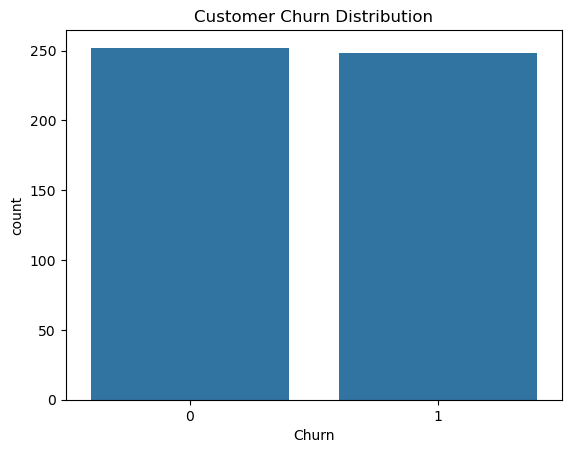

In [13]:
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

###  Age Distribution

In [ ]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

###  Balance Distribution

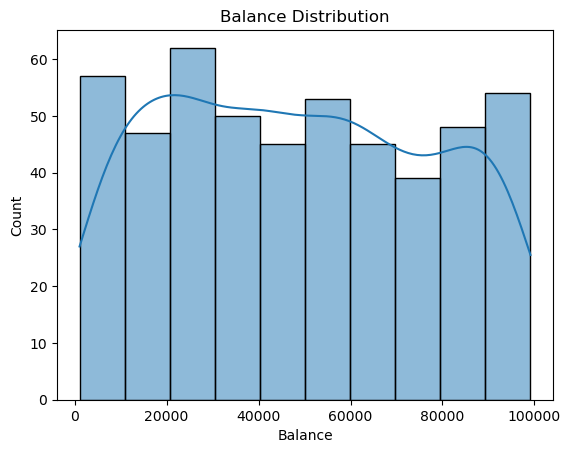

In [15]:
sns.histplot(df['Balance'], kde=True)
plt.title("Balance Distribution")
plt.show()

###  Salary Distribution

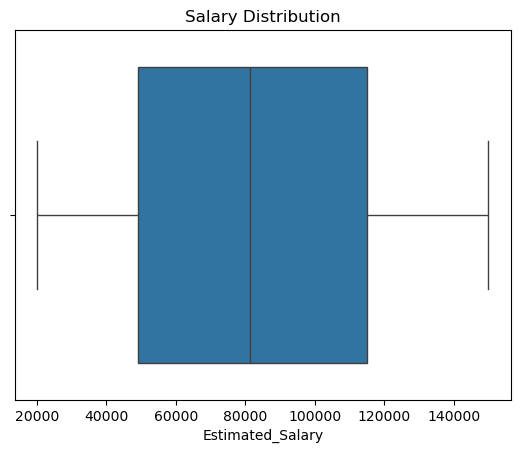

In [16]:
sns.boxplot(x=df['Estimated_Salary'])
plt.title("Salary Distribution")
plt.show()

###  Active Members Analysis

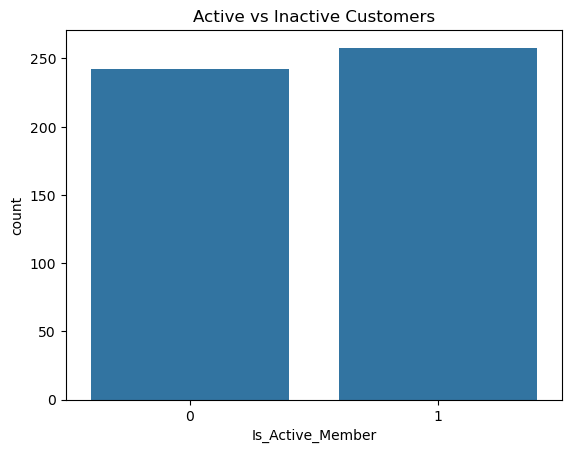

In [17]:
sns.countplot(x='Is_Active_Member', data=df)
plt.title("Active vs Inactive Customers")
plt.show()


###  Credit Card Analysis

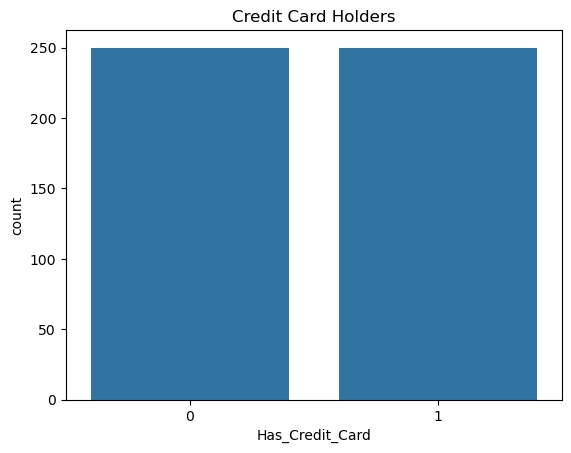

In [18]:
sns.countplot(x='Has_Credit_Card', data=df)
plt.title("Credit Card Holders")
plt.show()

### Product Usage Analysis

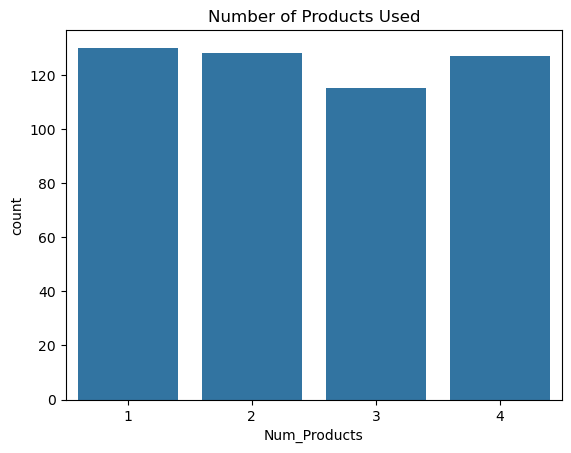

In [19]:
sns.countplot(x='Num_Products', data=df)
plt.title("Number of Products Used")
plt.show()

###  Churn vs Products

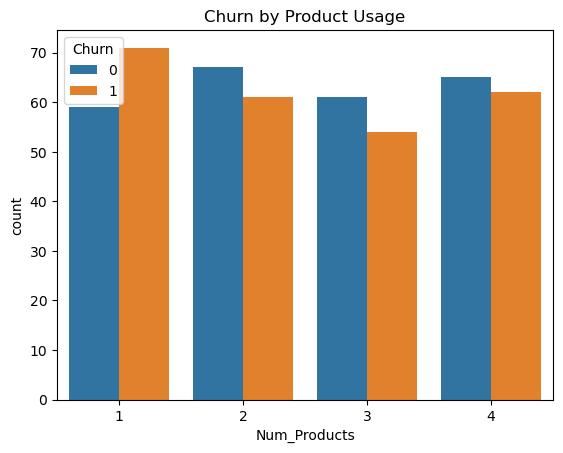

In [20]:
sns.countplot(x='Num_Products', hue='Churn', data=df)
plt.title("Churn by Product Usage")
plt.show()

##  Handle Outliers

In [21]:
numeric_cols = ['Age', 'Balance', 'Estimated_Salary']

z_scores = np.abs(zscore(df[numeric_cols]))

threshold = 3

outliers = df[(z_scores > threshold).any(axis=1)]

print("Outliers Shape:", outliers.shape)

Outliers Shape: (0, 8)


##  Correlation Analysis

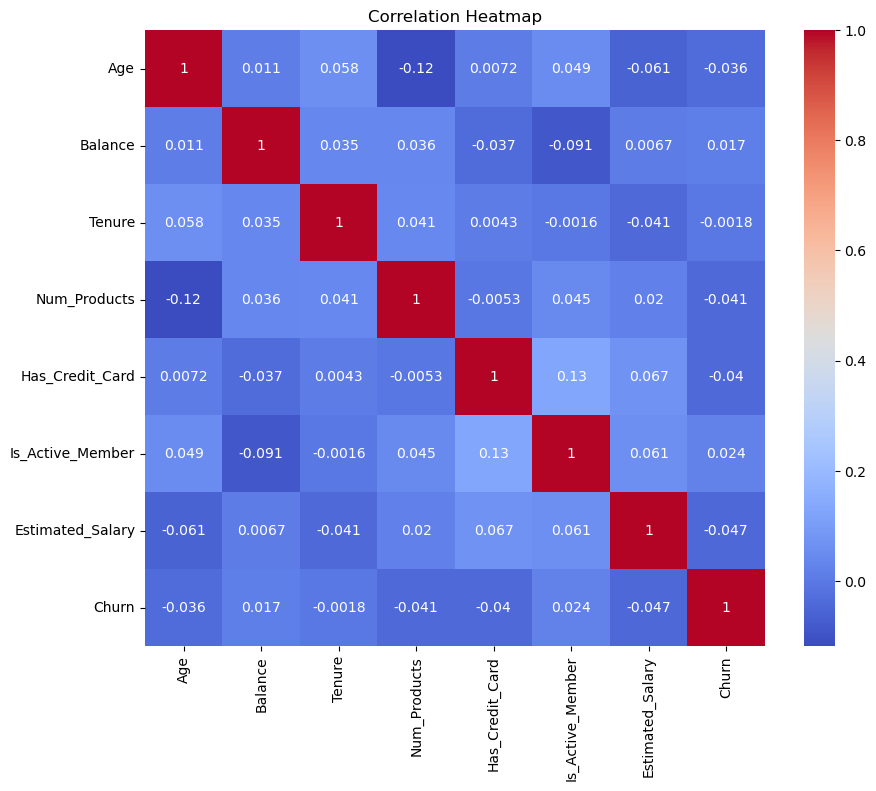

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

##  Feature Engineering

In [24]:
le = LabelEncoder()

df['Has_Credit_Card'] = le.fit_transform(df['Has_Credit_Card'])
df['Is_Active_Member'] = le.fit_transform(df['Is_Active_Member'])

## Split Features & Target

In [25]:
# X = Input Features
# y = Target Variable

X = df.drop('Churn', axis=1)
y = df['Churn']

##  Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

In [27]:
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

##   Logistic Regression Model

In [28]:
log_reg = LogisticRegression()

log_reg.fit(X_train, y_train)

# Predictions
y_pred_log = log_reg.predict(X_test)


##  Logistic Regression Evaluation

In [29]:
print("========== Logistic Regression ==========")

print("Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("Precision:",
      precision_score(y_test, y_pred_log))

print("Recall:",
      recall_score(y_test, y_pred_log))

print("F1 Score:",
      f1_score(y_test, y_pred_log))

print("ROC-AUC:",
      roc_auc_score(y_test, y_pred_log))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_log))

# Classification Report
print(classification_report(y_test, y_pred_log))

========== Logistic Regression ==========
Accuracy: 0.49
Precision: 0.6071428571428571
Recall: 0.2982456140350877
F1 Score: 0.4
ROC-AUC: 0.5212158302733578
[[32 11]
 [40 17]]
              precision    recall  f1-score   support

           0       0.44      0.74      0.56        43
           1       0.61      0.30      0.40        57

    accuracy                           0.49       100
   macro avg       0.53      0.52      0.48       100
weighted avg       0.54      0.49      0.47       100



## ROC Curve

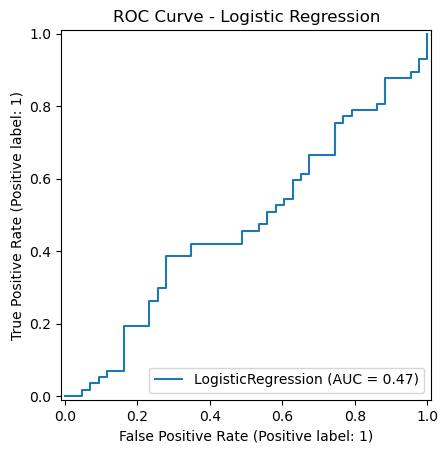

In [30]:
# ROC Curve measures model performance.

RocCurveDisplay.from_estimator(log_reg, X_test, y_test)

plt.title("ROC Curve - Logistic Regression")

plt.show()

##  Random Forest Model

In [31]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

##  Random Forest Evaluation

In [32]:
print("========== Random Forest ==========")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_pred_rf))

========== Random Forest ==========
Accuracy: 0.46
Precision: 0.5405405405405406
Recall: 0.3508771929824561
F1 Score: 0.425531914893617
ROC-AUC: 0.4777641778865768


###  Confusion Matrix

In [33]:
print(confusion_matrix(y_test, y_pred_rf))

[[26 17]
 [37 20]]


### Classification Report

In [34]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.41      0.60      0.49        43
           1       0.54      0.35      0.43        57

    accuracy                           0.46       100
   macro avg       0.48      0.48      0.46       100
weighted avg       0.49      0.46      0.45       100



##  Cross Validation

In [35]:
# Cross-validation checks model generalization.

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", cv_scores)

print("Average CV Score:",
      cv_scores.mean())

Cross Validation Scores: [0.4  0.48 0.5  0.46 0.49]
Average CV Score: 0.466


### Hyperparameter Tuning

In [36]:
# Improves model performance.

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3
)

grid_search.fit(X_train, y_train)

print("Best Parameters:",
      grid_search.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 50}


###  Feature Importance

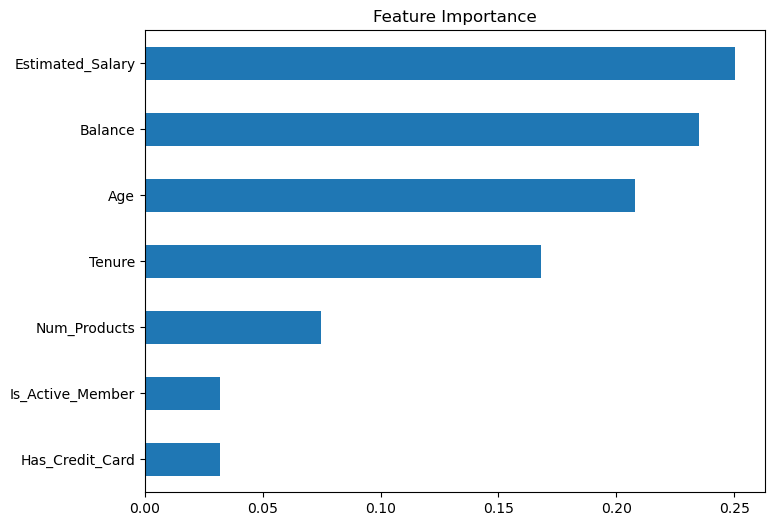

In [37]:
# Shows most important features for prediction.

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

feature_importance.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

### Overfitting Check

In [38]:
# Compare train vs test accuracy.

train_acc = rf.score(X_train, y_train)

test_acc = rf.score(X_test, y_test)

print("Train Accuracy:", train_acc)

print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.46


#  Final Business Insights

In [39]:
# Business insights are very important in real projects.

print("""
Business Insights:

1. Inactive customers are more likely to churn.

2. Customers with lower product usage show higher churn rates.

3. Age and Balance are important churn indicators.

4. Random Forest performed better than Logistic Regression.

5. Companies should focus on:
   - Customer engagement
   - Loyalty programs
   - Personalized offers
   - Retention strategies
""")


Business Insights:

1. Inactive customers are more likely to churn.

2. Customers with lower product usage show higher churn rates.

3. Age and Balance are important churn indicators.

4. Random Forest performed better than Logistic Regression.

5. Companies should focus on:
   - Customer engagement
   - Loyalty programs
   - Personalized offers
   - Retention strategies



#  Final Conclusion

In [40]:
print("""
Project Conclusion:

This project successfully predicted customer churn
using Machine Learning techniques.

Random Forest achieved strong performance and
identified important churn factors.

The project helps businesses reduce customer loss
and improve retention strategies.
""")



Project Conclusion:

This project successfully predicted customer churn
using Machine Learning techniques.

Random Forest achieved strong performance and
identified important churn factors.

The project helps businesses reduce customer loss
and improve retention strategies.



In [1]:
import os
os.getcwd()

'C:\\Users\\sonu4'